## 3장 1강: 다중 회귀와 규제 모델

### 4. Student Performance 데이터셋 분석
#### 3.1 데이터 준비 및 가공하기

머신러닝 데이터 가공과 시각화에 필요한 필수 도구들을 불러옵니다.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import sklearn

sklearn.set_config(display="text")


난수를 고정하여 매번 돌릴 때마다 동일한 분석 결과가 나오도록 처리

In [15]:
np.random.seed(42)

학생 성적(student-por.csv) 불러오기

In [16]:
df = pd.read_csv('student-por.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


분석을 위한 변수 3가지를 독립변수(특성, Feature)로 지정
- studytime: 주당 자습 시간 (1~4 범위)
- freetime: 방과 후 자유 시간 (1~5 범위)
- absences: 학기 중 최종 결석 횟수 (0~93 범위)

In [17]:
X = df[['studytime', 'freetime','absences']]
y = df['G3']

X[:5]

,studytime,freetime,absences
0,2,3,4
1,2,3,2
2,2,3,6
3,3,2,0
4,2,3,0


특성 공학(Polynomial Features)을 적용하여 3개의 기본 축을 제곱항과 상호작용항이 포함된 9개 컬럼으로 확장합니다.

In [18]:
poly = PolynomialFeatures(degree=2, include_bias=False)
#ploy.fit(X)   #준비 
#X_poly = poly.transform(X)  #변경

X_poly = poly.fit_transform(X)
X_poly.shape

(649, 9)

In [19]:
feature_names = poly.get_feature_names_out(X.columns) # 확장된 9개 특성의 이름을 확인합니다.
feature_names

array(['studytime', 'freetime', 'absences', 'studytime^2',
       'studytime freetime', 'studytime absences', 'freetime^2',
       'freetime absences', 'absences^2'], dtype=object)

자습 시간(1~4단계)과 결석 일수(0~93일)의 척도가 크게 다르므로, 이를 동일한 스케일(표준점수)로 맞춰줍니다.

In [20]:
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X_poly) # 표준점수로 변환
X_scaled[:5]

array([[ 0.08365295, -0.17164654,  0.07343336, -0.10972085, -0.02499704,
         0.15793558, -0.33462543,  0.02851214, -0.21578478],
       [ 0.08365295, -0.17164654, -0.35786305, -0.10972085, -0.02499704,
        -0.29661072, -0.33462543, -0.34912826, -0.35282562],
       [ 0.08365295, -0.17164654,  0.50472977, -0.10972085, -0.02499704,
         0.61248188, -0.33462543,  0.40615254,  0.01261663],
       [ 1.29011438, -1.12377133, -0.78915946,  1.21386342, -0.02499704,
        -0.75115702, -1.08921856, -0.72676866, -0.3985059 ],
       [ 0.08365295, -0.17164654, -0.78915946, -0.10972085, -0.02499704,
        -0.75115702, -0.33462543, -0.72676866, -0.3985059 ]])

#### 3.3 모델 학습 및 시각화

모델 학습 및 규제를 위한 도구를 불러옵니다.

In [21]:
from sklearn.linear_model import Ridge, Lasso


규제 강도(alpha)를 로그 스케일로 0.001부터 1000까지 넓은 범위에 걸쳐 200단계로 나누어 설정합니다.

In [22]:
alphas = np.logspace(-3, 3, 200)

모델 학습하기

In [27]:
ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    # 릿지(Ridge) 모델을 생성하고 학습한 뒤 가중치를 저장합니다.
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y)
    ridge_coefs.append(ridge.coef_)

    # Lasso 모델 가중치 저장
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_scaled, y)
    lasso_coefs.append(lasso.coef_)


시각화 하기

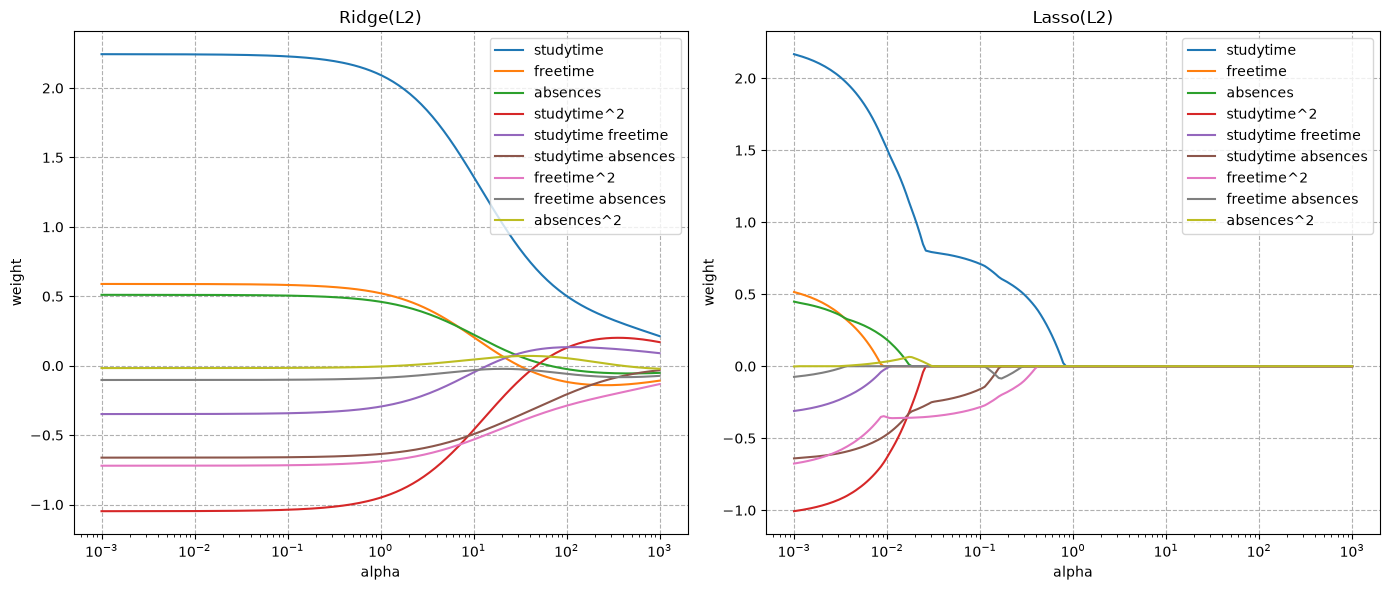

In [38]:
ridge_coefs=np.array(ridge_coefs)
lasso_coefs=np.array(lasso_coefs)

fig, axes = plt.subplots(1,2, figsize=(14,6))

#Ridge
for i in range(X_scaled.shape[1]):
    axes[0].plot(alphas, ridge_coefs[:,i], label=feature_names[i])

axes[0].set_xscale('log')   #alpha -> log
axes[0].set_title('Ridge(L2)')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('weight')
axes[0].grid(True, linestyle='--')
axes[0].legend()

#Lasso
for i in range(X_scaled.shape[1]):
    axes[1].plot(alphas, lasso_coefs[:,i], label=feature_names[i])

axes[1].set_xscale('log')   #alpha -> log
axes[1].set_title('Lasso(L2)')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('weight')
axes[1].grid(True, linestyle='--')
axes[1].legend()

plt.tight_layout()
plt.show()